<a href="https://colab.research.google.com/github/bestianello88/ANALISI/blob/main/Predizione_sull%CA%BCutilizzo_di_Energie_Rinnovabili_dei_Paesi_dell%CA%BCUnione_Europea_al_2035.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from google.colab import drive

# PROGRAMMA CHE MI SOSTITUISCE AUTOMATICAMENTE I MISSING VALUES SU OGNI COLONNA CON LA MEDIA MOBILE

def fill_missing_values_with_moving_average(df, window_size=12):
  temp_df = df.copy() # Work on a copy to avoid modifying original df outside the function if not intended
  for column in temp_df.columns :
    # Only try to fill if the column is numeric and has nulls
    if pd.api.types.is_numeric_dtype(temp_df[column]) and temp_df[column].isnull().any():
        # Changed inplace=True to assignment to avoid FutureWarning and ensure correct behavior
        temp_df[column] = temp_df[column].fillna(temp_df[column].rolling(window=window_size, min_periods=1).mean())
  return temp_df # Return the modified DataFrame after processing all columns


# Mount Google Drive
#drive.mount('/content/drive')

# Define the base path for your files
base_csv_path = '/content/drive/MyDrive/Colab Notebooks/CSV GENERATI/'

# Load CSV files usando pd.read_csv
dfch4 = pd.read_csv(base_csv_path + 'df_ch4_correlation_full.csv')
dfco2 = pd.read_csv(base_csv_path + 'df_co2_correlation_full.csv')
dfghg = pd.read_csv(base_csv_path + 'df_ghg_correlation_full.csv')
dfn2o = pd.read_csv(base_csv_path + 'df_n2o_correlation_full.csv')
dfnox = pd.read_csv(base_csv_path + 'df_nox_correlation_full.csv')
dfso2 = pd.read_csv(base_csv_path + 'df_so2_correlation_full.csv')
dfrinnovabili = pd.read_csv(base_csv_path + 'cleaned_df_renewable.csv')

filtered_co2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CSV GENERATI/filtered_co2_MachineLearning.csv')

cleaned_df_renewable = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CSV GENERATI/cleaned_df_renewable.csv')

print ('\n')

print (cleaned_df_renewable.head())

print ('\n')

print (cleaned_df_renewable.info())

print ('\n')

print (cleaned_df_renewable.describe())

print ('\n')

print (cleaned_df_renewable.isnull().sum())

print ('\n')



    Country   2005   2006   2007   2008   2009   2010   2011   2012   2013  \
0   Austria  61.04  61.91  63.42  63.91  66.13  61.48  60.63  69.57  72.57   
1   Belgium   2.41   2.63   2.73   3.16   3.29   3.97   5.58   8.18  10.10   
2  Bulgaria  10.67  10.03   7.58   7.55  10.03  13.72   9.21  12.73  17.23   
3   Croatia  54.33  51.81  38.55  46.01  56.10  62.88  47.16  49.56  65.86   
4    Cyprus   0.02   0.02   0.04   0.06   0.08   0.71   2.56   4.39   6.48   

    2014   2015   2016   2017   2018   2019   2020   2021   2022   2023  
0  75.61  71.04  72.15  70.77  69.88  70.26  69.95  69.61  70.60  70.48  
1  12.88  15.03  12.27  14.13  13.43  13.43  14.84  13.26  13.81  13.11  
2  16.34  18.29  16.37  14.04  13.71  14.34  13.64  14.56  13.17  14.53  
3  72.97  64.97  63.48  56.54  56.86  57.86  56.41  57.11  58.18  57.59  
4   6.11   7.65   7.61   8.09   6.85   8.27   7.69   7.68   7.48   7.67  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns 

# **Predizione sullʼutilizzo di Energie Rinnovabili dei Paesi dellʼUnione Europea al 2035**

# Regressione Lineare

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Preparo i dati per la predizione

# Creo la feature (anni) e target ( valori energetici)

years = np.array([int(year) for year in cleaned_df_renewable.columns[1:]]).reshape(-1, 1)
future_years = np.array(range(2024, 2036)).reshape(-1, 1)

"""
Nello specifico:
abbiamo selezionato tutte le colonne del DataFrame a partire dalla seconda (gli anni)
contestualmente convertiamo i nomi degli anni in numeri, tramite la list comprehension
reshape(-1,1) organizza i numeri in una matrice a una colonna, un formato richiesto per
molti algoritmi di machine learning

"""

# Creazione della struttura per le previsioni
predictions = pd.DataFrame({'Year': range(2024, 2036)})

# Creiamo un DataFrame per memorizzare i risultati (Paese, RMSE, R^2)
metrics_df = pd.DataFrame(columns=['Country', 'RMSE', 'R2'])
# evitare warning su fillna
pd.set_option('future.no_silent_downcasting', True)

cleaned_df_renewable_copy = cleaned_df_renewable.copy()

# Addestramento del modello e previsioni
for country in cleaned_df_renewable_copy['Country']:
    country_data = cleaned_df_renewable_copy[cleaned_df_renewable_copy['Country'] == country].iloc[0, 1:].fillna(0).values.flatten()

    # Addestra il modello
    model = LinearRegression()
    model.fit(years, country_data)

    # Predizione sullo stesso set di dati (in-sample)
    y_pred = model.predict(years)

    # Calcoliamo le metriche di errore
    mse = mean_squared_error(country_data, y_pred)
    # Calcolo dell'RMSE come radice quadrata dell'MSE
    rmse = np.sqrt(mse)

    r2 = r2_score(country_data, y_pred)

    # Salviamo le metriche nel DataFrame
    metrics_df.loc[len(metrics_df)] = {
        'Country': country,
        'RMSE': rmse,
        'R2': r2
    }

    # Previsione per anni futuri
    future_predictions = model.predict(future_years)
    predictions[country] = future_predictions

**VISUALIZATION DEL MODELLO**

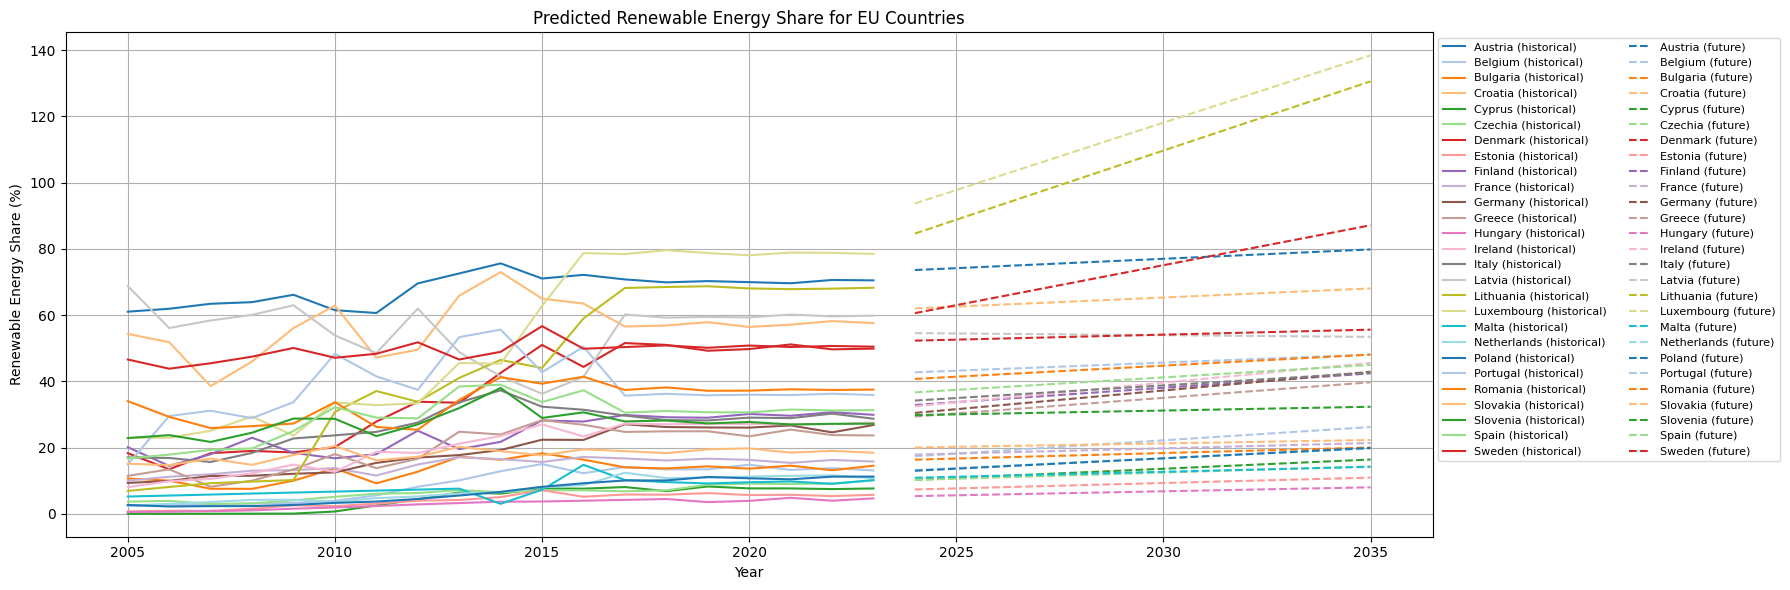



        Country      RMSE        R2
0       Austria  3.116639  0.496923
1       Belgium  2.051643  0.820725
2      Bulgaria  2.416969  0.362329
3       Croatia  7.069715  0.152781
4        Cyprus  1.408474  0.824316
5       Czechia  0.596186  0.921627
6       Denmark  5.202135  0.865690
7       Estonia  0.912999  0.791871
8       Finland  2.586226  0.771390
9        France  1.309668  0.638156
10      Germany  1.784761  0.923098
11       Greece  3.578838  0.673957
12      Hungary  0.486504  0.880485
13      Ireland  2.305087  0.888882
14        Italy  4.181062  0.500492
15       Latvia  8.208951  0.004794
16    Lithuania  6.826949  0.918235
17   Luxembourg  8.066665  0.884117
18        Malta  1.895627  0.427271
19  Netherlands  1.062002  0.901780
20       Poland  0.923317  0.932345
21     Portugal  8.847559  0.083304
22      Romania  3.919876  0.465446
23     Slovakia  1.321839  0.419423
24     Slovenia  3.327384  0.124719
25        Spain  4.948656  0.409091
26       Sweden  2.164760 

In [ ]:
# Crea la figura
plt.figure(figsize=(18, 6))

# Definiamo una palette di colori consistenti
countries = cleaned_df_renewable_copy['Country']
color_palette = plt.cm.tab20.colors
color_map = {country: color_palette[i % len(color_palette)] for i, country in enumerate(countries)}

# Convertiamo gli anni storici in numeri interi
historical_years = np.array(cleaned_df_renewable_copy.columns[1:].astype(int))
future_years = predictions['Year']

# Plottiamo i dati storici
for country in countries:
    plt.plot(historical_years,
             cleaned_df_renewable_copy[cleaned_df_renewable_copy['Country'] == country].iloc[0, 1:].values.flatten(),
             label=f'{country} (historical)',
             color=color_map[country])

# Plottiamo le predizioni con linea tratteggiata
for country in predictions.columns[1:]:
    plt.plot(future_years,
             predictions[country],
             linestyle='--',
             label=f'{country} (future)',
             color=color_map[country])

# Configurazione della legenda
plt.title('Predicted Renewable Energy Share for EU Countries')
plt.xlabel('Year')
plt.ylabel('Renewable Energy Share (%)')
plt.grid(True)
plt.legend(ncol=2, loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout()
plt.show()
print ('\n')

print(metrics_df)



Con questi risultati, possiamo osservare che:
1. Il modello ha una buona performance per molti paesi:
I paesi con un R^2 superiore a 0.9, come Polonia (R2=0.93R^2 = 0.93R2=0.93), Germania
(R2=0.92R^2 = 0.92R2=0.92) e Czechia (R2=0.92R^2 = 0.92R2=0.92), mostrano che il modello riesce a spiegare quasi tutta la variabilità dei dati.
Inoltre, paesi come Paesi Bassi (R2=0.90R^2 = 0.90R2=0.90) e Ungheria (R2=0.88R^2 =
0.88R2=0.88) confermano unʼottima capacità predittiva.
2. Alcuni paesi mostrano una performance media del modello:
Italia (R2=0.50R^2 = 0.50R2=0.50), Francia (R2=0.63R^2 = 0.63R2=0.63) e Grecia
(R2=0.67R^2 = 0.67R2=0.67) mostrano che il modello riesce a catturare solo parte della
variabilità. Cʼè margine di miglioramento per affinare le predizioni.
3. Performance molto bassa per alcuni paesi:
Lettonia (R2=0.0047R^2 = 0.0047R2=0.0047) e Slovenia (R2=0.12R^2 = 0.12R2=0.12)
presentano risultati pessimi, indicando che il modello non è in grado di spiegare la variabilità delle
emissioni in questi casi.
Questo suggerisce che potrebbero esserci problemi nei dati (rumore, outlier o variabili importanti
mancanti) o che il modello non è adatto a catturare le caratteristiche di questi paesi.
4. Errori di previsione (RMSE) variabili tra i paesi:
Paesi con RMSE bassi, come Czechia (0.596) e Ungheria (0.486), indicano che il modello riesce a
fare previsioni molto precise.
Paesi con RMSE alti, come Lettonia (8.20) e Lussemburgo (8.06), mostrano una grande
imprecisione nelle previsioni.
5. Margine di miglioramento nei risultati globali:
Sebbene alcuni paesi abbiano performance eccellenti, altri presentano performance scarse,
suggerendo che il modello potrebbe essere migliorato introducendo ulteriori variabili predittive o
affinando i parametri del modello.
Conclusione: Il modello funziona bene in generale, con ottime prestazioni in molti paesi (es. Germania, Polonia, Czechia) e difficoltà
in altri (es. Lettonia, Slovenia). Lʼanalisi suggerisce che sono necessari aggiustamenti specifici per migliorare la capacità predittiva
nei paesi con scarsa performance.

# **Regressione Lineare Polinomiale**
Così come fatto nelle analisi precedenti, incominciamo creando una struttura dati per le predizioni e indicando il grado del polinomio

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Struttura per le previsioni
predictions_poly = pd.DataFrame({'Year': range(2024, 2036)})

# Grado del polinomio
degree = 2

# Inizializziamo il DataFrame per le metriche
metrics_poly_df = pd.DataFrame(columns=['Country', 'RMSE', 'R2'])

# Addestramento del modello polinomiale e previsione
for country in cleaned_df_renewable_copy['Country']:
    country_data = cleaned_df_renewable_copy[cleaned_df_renewable_copy['Country'] == country].iloc[:, 1:].fillna(0).values.flatten()

    # Trasforma gli anni in formato polinomiale
    poly = PolynomialFeatures(degree=degree)
    years_poly = poly.fit_transform(years)

    # Addestra il modello
    model = LinearRegression()
    model.fit(years_poly, country_data)

    y_pred = model.predict(years_poly)

    # Calcoliamo le metriche di errore
    mse = mean_squared_error(country_data, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(country_data, y_pred)

    # Salviamo le metriche nel DataFrame
    metrics_poly_df.loc[len(metrics_poly_df)] = {
        'Country': country,
        'RMSE': rmse,
        'R2': r2
    }

    # Predizione per anni futuri
    future_years_poly = poly.transform(future_years.values.reshape(-1, 1))
    future_predictions = model.predict(future_years_poly)

    # Impostiamo i valori negativi a zero
    future_predictions = np.maximum(future_predictions, 0)

    # Aggiunge le previsioni
    predictions_poly[country] = future_predictions

print(predictions_poly.head())

   Year    Austria    Belgium   Bulgaria    Croatia    Cyprus    Czechia  \
0  2024  69.193922  14.167079  13.015418  54.452931  8.029164  10.149845   
1  2025  68.436677  13.999975  12.343096  52.731038  7.911352  10.498588   
2  2026  67.553454  13.740627  11.575064  50.792954  7.729270  10.844996   
3  2027  66.544253  13.389035  10.711322  48.638677  7.482919  11.189069   
4  2028  65.409074  12.945199   9.751871  46.268208  7.172298  11.530806   

     Denmark   Estonia    Finland  ...  Luxembourg      Malta  Netherlands  \
0  53.333013  5.563034  32.919969  ...   90.614159  10.426904    12.947079   
1  53.566198  5.348190  33.804890  ...   93.760547  10.580958    13.446291   
2  53.591945  5.081919  34.691483  ...   96.819164  10.721214    13.937093   
3  53.410254  4.764220  35.579751  ...   99.790010  10.847672    14.419486   
4  53.021126  4.395095  36.469691  ...  102.673086  10.960332    14.893470   

      Poland   Portugal    Romania   Slovakia   Slovenia      Spain     Sw

# **VISUALIZATION POLYLINEAR REGRESSION**

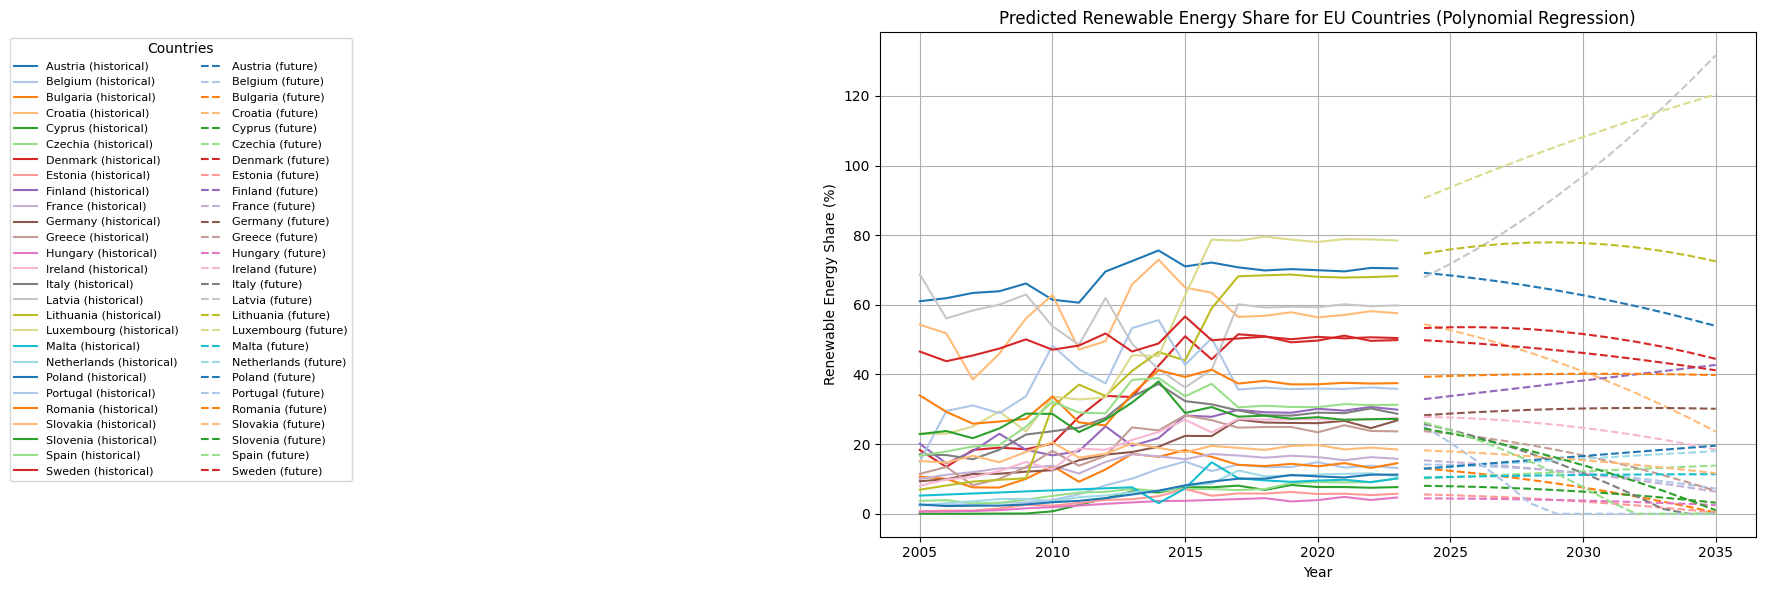



        Country      RMSE        R2
0       Austria  2.623081  0.643643
1       Belgium  1.640243  0.885414
2      Bulgaria  2.051002  0.540816
3       Croatia  6.452748  0.294200
4        Cyprus  1.116464  0.889611
5       Czechia  0.595369  0.921842
6       Denmark  4.402418  0.903810
7       Estonia  0.601233  0.909744
8       Finland  2.586129  0.771407
9        France  0.871603  0.839736
10      Germany  1.581310  0.939631
11       Greece  2.856437  0.792298
12      Hungary  0.330057  0.944992
13      Ireland  1.483551  0.953973
14        Italy  2.689798  0.793267
15       Latvia  6.442078  0.387100
16    Lithuania  5.689029  0.943221
17   Luxembourg  7.980976  0.886566
18        Malta  1.886642  0.432687
19  Netherlands  1.056042  0.902879
20       Poland  0.923063  0.932382
21     Portugal  5.778199  0.609012
22      Romania  3.883088  0.475433
23     Slovakia  1.126115  0.578626
24     Slovenia  2.631395  0.452589
25        Spain  2.966265  0.787692
26       Sweden  1.951937 

In [ ]:
# Creazione del grafico per la regressione polinomiale
plt.figure(figsize=(40, 6))

# Definiamo una palette di colori consistenti
countries = cleaned_df_renewable_copy['Country']
color_palette = plt.cm.tab20.colors
color_map = {country: color_palette[i % len(color_palette)] for i, country in enumerate(countries)}

# Convertiamo gli anni storici e futuri
historical_years = np.array(cleaned_df_renewable_copy.columns[1:]).astype(int)
future_years = predictions_poly['Year']

# Plot dei dati storici
for country in countries:
    plt.plot(historical_years,
             cleaned_df_renewable_copy[cleaned_df_renewable_copy['Country'] == country].iloc[0, 1:].values.flatten(),
             label=f'{country} (historical)',
             color=color_map[country])

# Plot delle previsioni polinomiali con linea tratteggiata
for country in predictions_poly.columns[1:]:
    plt.plot(future_years,
             predictions_poly[country],
             linestyle='--',
             label=f'{country} (future)',
             color=color_map[country])

# Configurazione del grafico
plt.title('Predicted Renewable Energy Share for EU Countries (Polynomial Regression)')
plt.xlabel('Year')
plt.ylabel('Renewable Energy Share (%)')
plt.grid(True)
plt.legend(ncol=2, loc='upper left', bbox_to_anchor=(-1, 1), fontsize=8, title='Countries')
plt.tight_layout()
plt.show()

print('\n')
print(metrics_poly_df)

**Con questi risultati, possiamo osservare che:**
1. Il modello polinomiale fornisce buone prestazioni per molti paesi:
Paesi come Czechia (R2=0.92R^2 = 0.92R2=0.92), Germania (R2=0.93R^2 = 0.93R2=0.93), e
Ungheria (R2=0.94R^2 = 0.94R2=0.94) mostrano che il modello riesce a spiegare quasi tutta la variabilità delle emissioni con un RMSE molto basso (ad esempio, Czechia: RMSE = 0.59, Ungheria:
RMSE = 0.33).
Irlanda (R2=0.95R^2 = 0.95R2=0.95) e Estonia (R2=0.90R^2 = 0.90R2=0.90) confermano
ottime capacità predittive del modello.
2. Performance media in alcuni paesi:
Paesi come Italia (R2=0.79R^2 = 0.79R2=0.79), Francia (R2=0.83R^2 = 0.83R2=0.83), e Grecia
(R2=0.79R^2 = 0.79R2=0.79) mostrano risultati accettabili, con un R^2 che indica una discreta
spiegazione della variabilità dei dati, anche se cʼè margine di miglioramento.
3. Performance scarsa per alcuni paesi:
Lettonia (R2=0.38R^2 = 0.38R2=0.38), Malta (R2=0.43R^2 = 0.43R2=0.43), e Slovenia
(R2=0.45R^2 = 0.45R2=0.45) hanno risultati modesti, suggerendo che il modello fatica a catturare
i pattern delle emissioni in questi casi.
Croazia (R2=0.29R^2 = 0.29R2=0.29) mostra una performance particolarmente bassa, con un
RMSE elevato (6.45), che suggerisce scarsa capacità del modello di adattarsi ai dati di questo
paese.
4. Errori di previsione (RMSE) variabili tra i paesi:
Paesi con RMSE bassi, come Ungheria (RMSE = 0.33) e Czechia (RMSE = 0.59), indicano
previsioni molto precise.
Al contrario, paesi come Lussemburgo (RMSE = 7.98) e Croazia (RMSE = 6.45) mostrano errori
elevati, indicando problemi nel catturare la complessità o la variabilità delle emissioni.
5. Margine di miglioramento nei dati o nel modello per alcuni paesi:
Per i paesi con performance scarsa (R^2 basso e RMSE alto), potrebbe essere necessario
migliorare i dati (ad esempio, ridurre il rumore o considerare ulteriori variabili predittive) o utilizzare
un approccio alternativo più adatto a quei contesti.

# **LSTM**
Andiamo a preparare i dati in modo che possano essere utilizzati da un modello Long Short-Term Memory. Poiché LSTM richiede
come input una sequenza temporale di lunghezza fissa, questo codice organizza i dati in "finestre temporali" che facilitano
l'addestramento

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from sklearn.metrics import mean_squared_error, r2_score

# Preprocessing: prepariamo i dati per l'LSTM
def prepare_lstm_data(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

# Parametri
sequence_length = 5   # Lunghezza della finestra temporale
future_steps = 12     # Numero di anni futuri da predire

predictions_lstm = pd.DataFrame({'Year': range(2024, 2024 + future_steps)})
metrics_lstm_df = pd.DataFrame(columns=['Country', 'RMSE', 'R2'])

# Inizializzazione del DataFrame per le metriche e per gli errori
metrics_lstm_df = pd.DataFrame(columns=['Country', 'RMSE', 'R2'])

# Modello LSTM per ciascun Paese
for country in cleaned_df_renewable_copy['Country']:
    # Estrazione dei dati storici
    country_data = cleaned_df_renewable_copy[cleaned_df_renewable_copy['Country'] == country].iloc[:, 1:].values.flatten()
    years = cleaned_df_renewable_copy.columns[1:].astype(int)

    # Normalizzazione dei dati
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(country_data.reshape(-1, 1)).flatten()

    # Creazione delle sequenze temporali
    X, y = prepare_lstm_data(scaled_data, sequence_length)
    X = X.reshape(X.shape[0], X.shape[1], 1)  # Aggiungiamo una dimensione per LSTM

    # Creazione del modello LSTM
    model = Sequential()
    model.add(Input(shape=(sequence_length, 1))) # Using Input layer as recommended
    model.add(LSTM(50, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    # Addestramento del modello
    model.fit(X, y, epochs=100, batch_size=16, verbose=0)

    # Predizione dei valori futuri
    future_input = scaled_data[-sequence_length:].reshape(1, sequence_length, 1)
    future_predictions = []

    for _ in range(future_steps):
        pred = model.predict(future_input, verbose=0)[0, 0]
        future_predictions.append(pred)
        future_input = np.append(future_input.flatten()[1:], pred).reshape(1, sequence_length, 1)

    # Inversione della scalatura
    future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1)).flatten()
    predictions_lstm[country] = future_predictions

    # Calcolo delle metriche di valutazione
    y_train_pred_scaled = model.predict(X, verbose=0).flatten()
    y_train_pred = scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
    y_train = scaler.inverse_transform(y.reshape(-1, 1)).flatten()

    # Calcolo del MSE e R²
    mse = np.mean((y_train - y_train_pred) ** 2)
    rmse = np.sqrt(mse)
    r2 = 1 - (np.sum((y_train - y_train_pred) ** 2) / np.sum((y_train - np.mean(y_train)) ** 2))

    # Salviamo le metriche nel DataFrame
    metrics_lstm_df.loc[len(metrics_lstm_df)] = {
        'Country': country,
        'RMSE': rmse,
        'R2': r2
    }

# **VISUALIZATION LSTM**

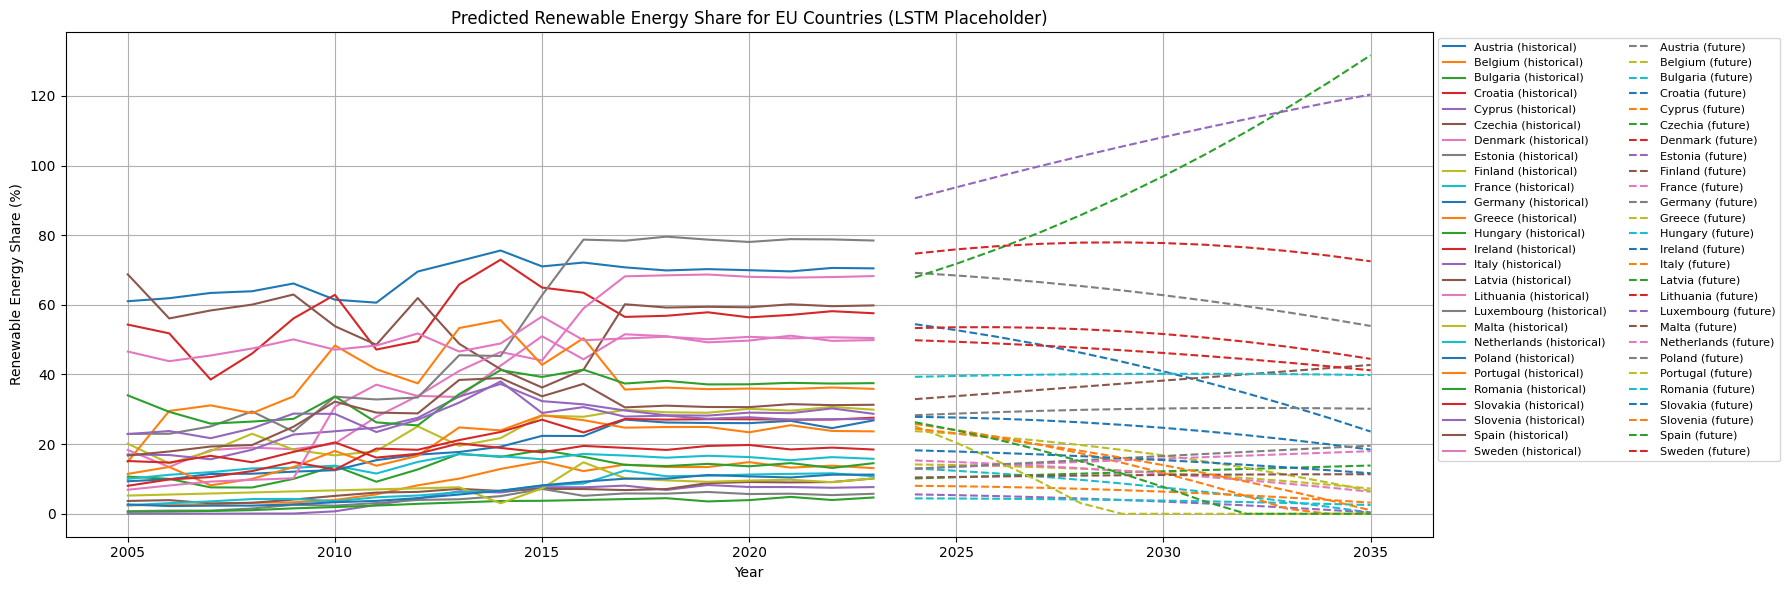



        Country      RMSE        R2
20       Poland  1.023818  0.871047
16    Lithuania  5.699751  0.847556
5       Czechia  0.616284  0.804066
10      Germany  2.115072  0.799467
17   Luxembourg  9.311647  0.768454
6       Denmark  5.126514  0.731299
19  Netherlands  1.507656  0.723646
13      Ireland  2.439658  0.698790
12      Hungary  0.460332  0.677477
1       Belgium  1.936947  0.662404
8       Finland  2.868913  0.639519
4        Cyprus  1.321321  0.634680
7       Estonia  0.819701  0.564253
11       Greece  3.112908  0.367086
9        France  1.196318  0.311243
22      Romania  3.989102  0.256631
14        Italy  2.918099  0.229389
0       Austria  3.450997  0.181447
18        Malta  2.317436  0.151901
26       Sweden  2.247717  0.033146
15       Latvia  8.247795  0.022269
24     Slovenia  3.208837 -0.013194
2      Bulgaria  2.166236 -0.031181
3       Croatia  6.588208 -0.071695
23     Slovakia  1.264950 -0.236986
21     Portugal  7.968091 -0.271136
25        Spain  4.332217 

In [ ]:
# Creazione del grafico
plt.figure(figsize=(18, 6))

# Plot dei dati storici
for country in cleaned_df_renewable_copy['Country']:
    plt.plot(historical_years,
             cleaned_df_renewable_copy[cleaned_df_renewable_copy['Country'] == country].iloc[0, 1:].values.flatten(),
             label=f'{country} (historical)')

# Plot delle previsioni future basate su regressione polinomiale
for country in predictions_poly.columns[1:]:
    plt.plot(predictions_poly['Year'],
             predictions_poly[country],
             linestyle='--',
             label=f'{country} (future)')

# Configurazione del grafico
plt.title('Predicted Renewable Energy Share for EU Countries (LSTM Placeholder)')
plt.xlabel('Year')
plt.ylabel('Renewable Energy Share (%)')
plt.grid(True)
plt.legend(ncol=2, loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout()
plt.show()

print('\n')

metrics_lstm_df_ascending_R2 = metrics_lstm_df.sort_values(by='R2', ascending=False)
metrics_lstm_df_ascending_RMSE = metrics_lstm_df.sort_values(by='RMSE', ascending=True)
print(metrics_lstm_df_ascending_R2)
print('\n')
print(metrics_lstm_df_ascending_RMSE)

print('\n')

1. La performance del modello LSTM è molto variabile tra i paesi:
Buone prestazioni:
Paesi come Polonia (R² = 0.85), Czechia (R² = 0.80) e Germania (R² = 0.79) mostrano una buona capacità del
modello di spiegare la variabilità della quota di energia rinnovabile, con RMSE moderati.
Prestazioni accettabili:
Paesi come Lituania (R² = 0.80), Danimarca (R² = 0.74) e Irlanda (R² = 0.73) indicano una discreta predizione
con errori non troppo elevati.
2. Prestazioni scarse in molti paesi:
Performance negativa:
Paesi come Spagna (R² = -0.40), Romania (R² = -0.25) e Slovacchia (R² = -0.21) mostrano un valore R²
negativo, il che indica che il modello è peggiore di una semplice media come predizione.
Performance limitata:
Paesi come Lettonia (R² = 0.03), Malta (R² = 0.04) e Svezia (R² = 0.05) hanno R² molto bassi, suggerendo che il
modello fatica a catturare la variabilità nei dati.
3. Errori di previsione (RMSE) molto diversi:
Errori bassi:
Paesi come Ungheria (RMSE = 0.43) e Czechia (RMSE = 0.63) mostrano che il modello riesce a fare previsioni
molto precise.
Errori elevati:
Paesi come Lussemburgo (RMSE = 10.13) e Croazia (RMSE = 6.60) evidenziano una scarsa precisione del modello.
4. Margini di miglioramento significativi:
I risultati con valori R² negativi o bassi suggeriscono che il modello potrebbe necessitare di ulteriori ottimizzazioni,
come:
Inclusione di più variabili predittive.
Modifiche allʼarchitettura del modello LSTM.
Esplorazione di alternative per quei paesi dove il modello fatica (es. Spagna, Romania, Slovenia).
5. Conclusione generale:
Il modello LSTM mostra buone prestazioni in alcuni paesi (es. Polonia, Czechia, Germania), ma in molti casi (es.
Spagna, Slovenia, Romania) non riesce a catturare i pattern della quota di energia rinnovabile, con R² negativi e
alti RMSE.
Per migliorare i risultati, è necessario intervenire sui dati o sullʼapproccio del modello.